In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/audio-dataset/834608010218654.wav
/kaggle/input/audio-dataset/11992.wav
/kaggle/input/audio-dataset/834608004582894_2.wav
/kaggle/input/audio-dataset/download.wav
/kaggle/input/audio-dataset/834608004582894.wav
/kaggle/input/audio-dataset/audiomass-output2.wav
/kaggle/input/audio-dataset/834608004032583.wav
/kaggle/input/audio-dataset/16000.wav
/kaggle/input/audio-dataset/834608007007257.wav
/kaggle/input/audio-dataset/audiomass-output.wav
/kaggle/input/audio-dataset/cs_dataset/cs_dataset/database.yml
/kaggle/input/audio-dataset/cs_dataset/cs_dataset/audio/834608004576951.wav
/kaggle/input/audio-dataset/cs_dataset/cs_dataset/audio/834608004574706.wav
/kaggle/input/audio-dataset/cs_dataset/cs_dataset/audio/834608004579439.wav
/kaggle/input/audio-dataset/cs_dataset/cs_dataset/audio/834608004581336.wav
/kaggle/input/audio-dataset/cs_dataset/cs_dataset/audio/834608004359857.wav
/kaggle/input/audio-dataset/cs_dataset/cs_dataset/audio/834608004572266.wav
/kaggle/input/audio-dat

In [2]:
!pip install librosa

In [3]:
import librosa
import numpy as np

file_path = "/kaggle/input/audio-dataset/834608004032583.wav"

# 1. Load audio
signal, sr = librosa.load(file_path, sr=16000, mono=True)
print(f"Sample rate: {sr}")
print(f"Duration (sec): {len(signal)/sr:.2f}")

frame_length = int(0.025 * sr)   # 400 samples
hop_length   = int(0.010 * sr)   # 160 samples

# 2. Extract Frames
# We extract frames once and use them for energy and entropy
frames = librosa.util.frame(
    signal, 
    frame_length=frame_length, 
    hop_length=hop_length
) # Shape: (frame_length, n_frames)

# 3. Short-Term Energy (Optimized)
energy = np.sum(frames**2, axis=0)

# 4. Zero-Crossing Rate
# Added center=False to prevent length mismatches
zcr = librosa.feature.zero_crossing_rate(
    signal,
    frame_length=frame_length,
    hop_length=hop_length,
    center=False 
)[0]

# 5. Spectral Entropy (Vectorized for Speed)
def spectral_entropy_vectorized(frames):
    # np.fft.rfft automatically computes just the positive frequencies
    spectrum = np.abs(np.fft.rfft(frames, axis=0))**2
    
    # Add epsilon to avoid division by zero
    prob = spectrum / (np.sum(spectrum, axis=0, keepdims=True) + 1e-12)
    entropy = -np.sum(prob * np.log2(prob + 1e-12), axis=0)
    
    return entropy

entropy = spectral_entropy_vectorized(frames)

# 6. Pitch (YIN)
# Added center=False to prevent length mismatches
pitch = librosa.yin(
    signal,
    fmin=80,     
    fmax=400,
    sr=sr,
    frame_length=frame_length,
    hop_length=hop_length,
    center=False 
)

# 7. MFCC
# Added center=False to prevent length mismatches
mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=13,
    n_fft=frame_length,
    hop_length=hop_length,
    center=False 
)
mfcc = mfcc.T   # shape: (n_frames, 13)

# Verify that all features have the exact same number of frames
print("\n--- Feature Shapes ---")
print(f"Energy shape:  {energy.shape}")
print(f"ZCR shape:     {zcr.shape}")
print(f"Entropy shape: {entropy.shape}")
print(f"Pitch shape:   {pitch.shape}")
print(f"MFCC shape:    {mfcc.shape}")

Sample rate: 16000
Duration (sec): 21.57

--- Feature Shapes ---
Energy shape:  (2155,)
ZCR shape:     (2155,)
Entropy shape: (2155,)
Pitch shape:   (2155,)
MFCC shape:    (2155, 13)


/tmp/ipykernel_55/1399627781.py:49: UserWarning: With fmin=80.000, sr=16000 and frame_length=400, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=80.000 or frame_length=401.
  pitch = librosa.yin(


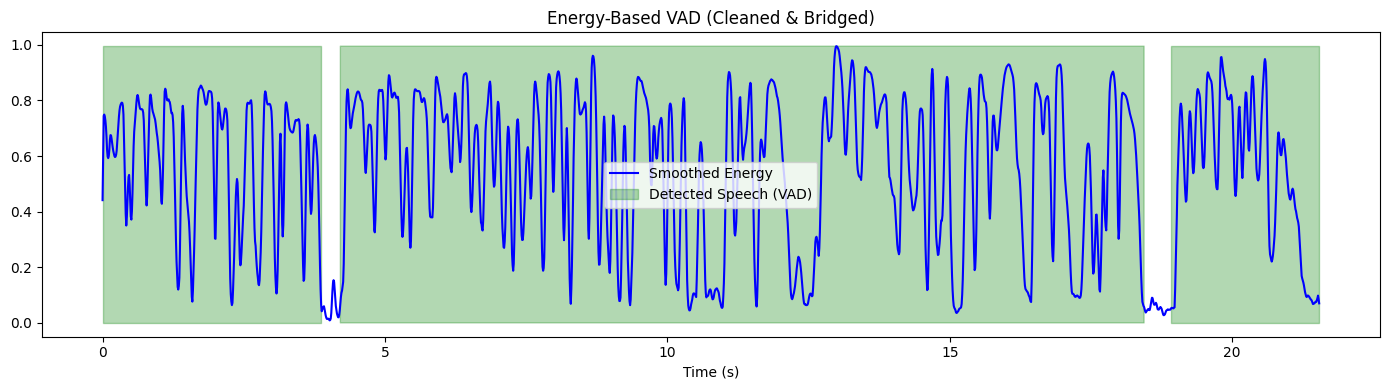

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt

# --- 1. Stacking Features ---
# Note: I removed spectral_flux since it is undefined. 
# If you used the center=False fix from earlier, min_len isn't strictly needed, 
# but it's a great safety net!
min_len = min(len(energy), len(zcr), len(entropy), len(pitch), len(mfcc))

features = np.column_stack([
    energy[:min_len],
    zcr[:min_len],
    entropy[:min_len],
    pitch[:min_len],
    mfcc[:min_len]
])

# --- 2. Energy Smoothing ---
energy_log = np.log(energy + 1e-12)
energy_norm = (energy_log - energy_log.min()) / (energy_log.max() - energy_log.min())

# You can use median filter OR convolve. Let's stick to your convolve logic for the mask.
threshold = 0.05
window = 5   

energy_smooth = np.convolve(
    energy_norm,
    np.ones(window)/window,
    mode='same'
)

# Initial raw mask
speech_mask = energy_smooth > threshold

# --- 3. VAD Cleanup: Remove short speech segments ---
min_frames = int(0.2 / (hop_length / sr))
clean_mask = speech_mask.copy()
count = 0

for i in range(len(speech_mask)):
    if speech_mask[i]:
        count += 1
    else:
        if 0 < count < min_frames:
            clean_mask[i-count:i] = False
        count = 0
# Edge case: check if signal ended on a short segment
if 0 < count < min_frames:
    clean_mask[len(speech_mask)-count:] = False

# --- 4. VAD Cleanup: Bridge short gaps ---
min_gap = int(0.15 / (hop_length / sr)) 

# CRITICAL FIX: Use clean_mask here, not the raw speech_mask!
final_mask = clean_mask.copy()
count = 0

for i in range(len(final_mask)):
    if not final_mask[i]:
        count += 1
    else:
        if 0 < count < min_gap:
            final_mask[i-count:i] = True
        count = 0
# Edge case: check if signal ended on a short gap
if 0 < count < min_gap:
    final_mask[len(final_mask)-count:] = True

# --- 5. Plotting ---
frame_times = np.arange(len(energy)) * hop_length / sr

plt.figure(figsize=(14,4))
plt.plot(frame_times, energy_smooth, label="Smoothed Energy", color="blue")

# CRITICAL FIX: Use final_mask here
plt.fill_between(frame_times,
                 0,
                 np.max(energy_smooth), # Fill to top of chart for clarity
                 where=final_mask,
                 alpha=0.3,
                 color="green",
                 label="Detected Speech (VAD)")

plt.title("Energy-Based VAD (Cleaned & Bridged)")
plt.xlabel("Time (s)")
plt.legend()
plt.tight_layout()
plt.show()

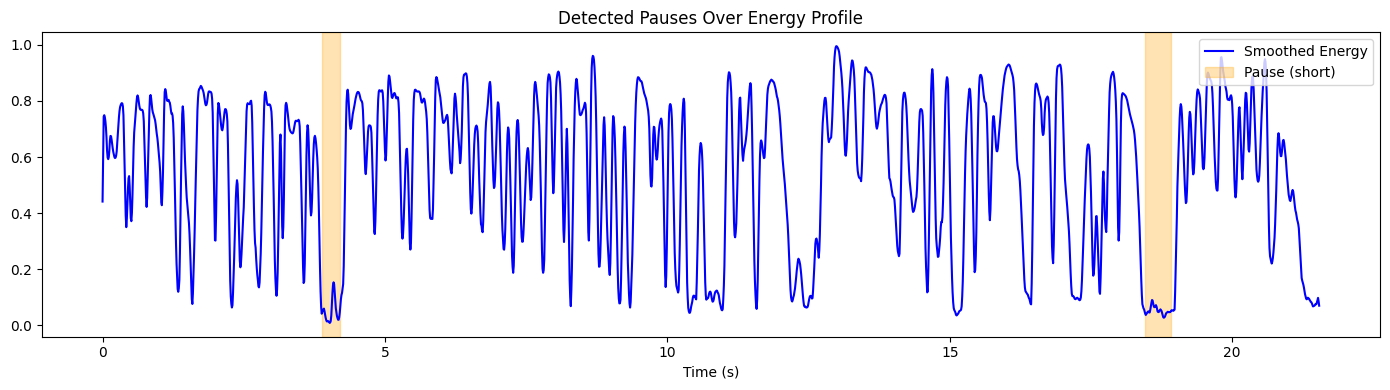

Total pauses found: 2
Potential breath pauses found: 2


In [5]:
# --- 1. Find Pauses using the correct mask ---
pauses = []
start = None

# FIX: Use final_mask instead of mask
for i, val in enumerate(final_mask):
    if not val and start is None:
        start = i
    elif val and start is not None:
        pauses.append((start, i))
        start = None

if start is not None:
    pauses.append((start, len(final_mask)))

# --- 2. Filter Valid Pauses (ignore edges) ---
valid_pauses = []
for s, e in pauses:
    # FIX: Use len(final_mask)
    if s > 0 and e < len(final_mask):
        valid_pauses.append((s, e))

# --- 3. Get Pause Info & Types ---
typed_pauses = []
for s, e in valid_pauses:
    duration = (e - s) * hop_length / sr
    
    if duration < 0.2:
        label = "micro"
    elif duration < 0.5:
        label = "short"
    elif duration < 1.0:
        label = "medium"
    else:
        label = "long"
        
    typed_pauses.append((s, e, duration, label))

# --- 4. Detect Breaths ---
breath_pauses = []
for s, e, d, label in typed_pauses:
    # Ensure slice is not empty to avoid warnings
    if s == e: continue 
        
    z = np.mean(zcr[s:e])
    en = np.mean(energy_norm[s:e])
    
    # FIX: Removed the strictly 'p == 0' pitch condition. 
    # Breaths typically have low energy but high zero-crossing rates (hissing sound).
    # You can adjust these thresholds as needed based on your specific audio.
    if (en > 0.005) and (z > 0.10): 
        breath_pauses.append((s, e, d, "breath"))

# --- 5. Plotting ---
plt.figure(figsize=(14,4))

# FIX: Use energy_smooth instead of energy_env
plt.plot(frame_times, energy_smooth, label="Smoothed Energy", color="blue")

# FIX: Loop over typed_pauses (or breath_pauses if you only want to see breaths)
for s, e, d, label in typed_pauses:
    plt.axvspan(s * hop_length / sr,
                e * hop_length / sr,
                alpha=0.3,
                color="red" if label == "micro" else "orange", # Color coding for visuals
                label=f"Pause ({label})" if f"Pause ({label})" not in plt.gca().get_legend_handles_labels()[1] else "")

plt.title("Detected Pauses Over Energy Profile")
plt.xlabel("Time (s)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print out findings to verify
print(f"Total pauses found: {len(typed_pauses)}")
print(f"Potential breath pauses found: {len(breath_pauses)}")

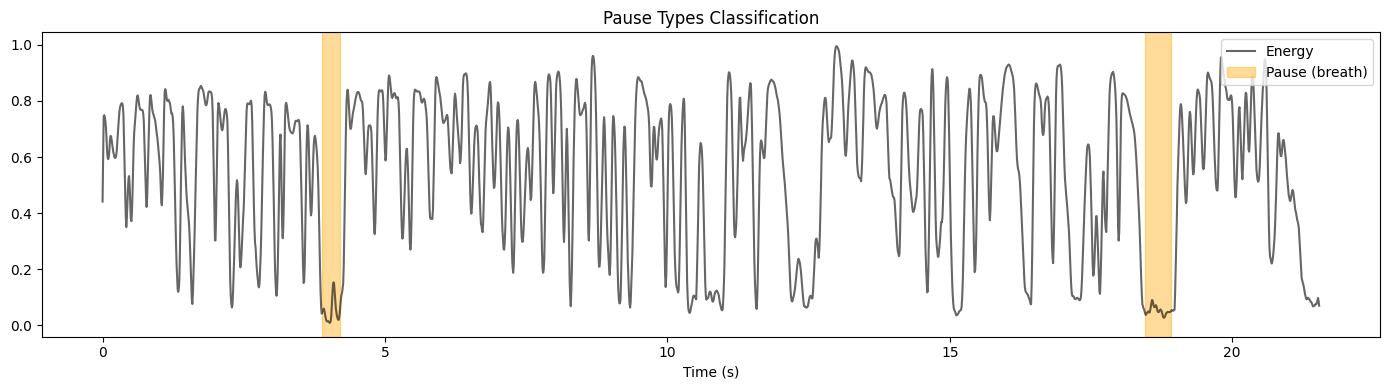

Classification Summary:
 - breath: 2


In [6]:
# --- 1. Extract Features for Pauses ---
pause_features = []

for s, e, d, _ in typed_pauses:
    # Prevent empty slices from causing np.mean() warnings
    if s == e: continue 

    f = {
        "duration": d,
        "energy": np.mean(energy_smooth[s:e]), # FIX: Use energy_smooth
        "zcr": np.mean(zcr[s:e]),
        "entropy": np.mean(entropy[s:e]),
        "pitch": np.mean(pitch[s:e])
    }
    pause_features.append((s, e, f))

# --- 2. Classify Pauses ---
classified = []

for s, e, f in pause_features:
    d = f["duration"]
    en = f["energy"]
    z = f["zcr"]
    ent = f["entropy"]
    p = f["pitch"]

    # REVISED LOGIC: Since pitch is never 0, we use ZCR to separate breaths from filled pauses
    if d > 1.0:
        label = "long_pause"
        
    elif en < 0.05: 
        # Very quiet -> Silent Pause
        label = "silent"

    elif en >= 0.05 and z > 0.10: 
        # Higher energy but high zero-crossing -> Noisy/Hissing -> Breath
        label = "breath"

    elif en >= 0.05 and z <= 0.10: 
        # Higher energy, low zero-crossing -> Vowel-like tone -> Filled Pause ("umm", "ahh")
        label = "filled"

    else:
        label = "hesitation"

    classified.append((s, e, d, label))

# --- 3. Plotting ---
colors = {
    "silent": "blue",
    "breath": "orange",
    "filled": "green",
    "hesitation": "purple",
    "long_pause": "red"
}

plt.figure(figsize=(14,4))
# FIX: Use energy_smooth
plt.plot(frame_times, energy_smooth, label="Energy", color="black", alpha=0.6) 

for s, e, d, label in classified:
    plt.axvspan(
        s * hop_length / sr,
        e * hop_length / sr,
        color=colors.get(label, "gray"),
        alpha=0.4,
        # Only add label to legend once per category to keep it clean
        label=f"Pause ({label})" if f"Pause ({label})" not in plt.gca().get_legend_handles_labels()[1] else ""
    )

plt.title("Pause Types Classification")
plt.xlabel("Time (s)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print out a summary of what we classified
from collections import Counter
counts = Counter([label for _, _, _, label in classified])
print("Classification Summary:")
for lbl, count in counts.items():
    print(f" - {lbl}: {count}")

In [7]:
!pip install -U openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.4 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 9.2 MB/s eta 0:00:00:00:0100:01
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803980 sha256=b34667facc503588a55c14b9da6ee7f2d524ff22e9cad73b668cff86f72d3274
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


Loading Whisper model (this might take a moment)...
Transcribing audio...


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Extracted 86 words from the audio.

--- Semantic Pause Analysis ---
Pause 1: 3.88s - 4.21s | 0.33s | breath_pause
   Context: [... em.] -> (PAUSE) -> [mình, ...]

Pause 2: 18.45s - 18.92s | 0.47s | breath_pause
   Context: [... thế.] -> (PAUSE) -> [Anh ...]



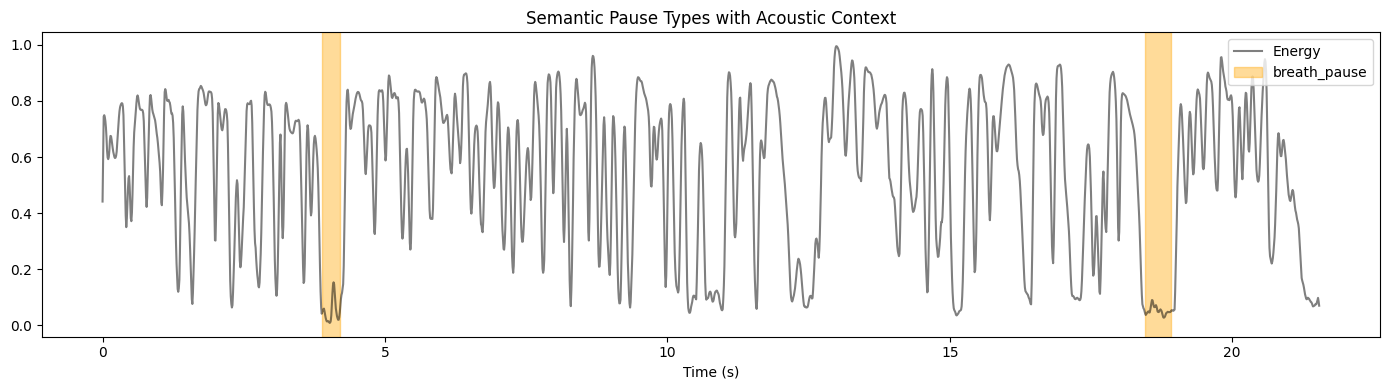

In [14]:
import whisper
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Run ASR (Whisper) to get Word Timestamps ---
print("Loading Whisper model (this might take a moment)...")
# 'base' or 'small' is fine for testing. Use 'large-v2' for best Vietnamese accuracy later.
model = whisper.load_model("base") 

print("Transcribing audio...")
# word_timestamps=True is CRITICAL for this stage
result = model.transcribe(file_path, language="vi", word_timestamps=True)

# Extract word-level timestamps into the format your logic expects
words = []
for segment in result['segments']:
    for word in segment['words']:
        # Format: (word_text, start_time, end_time)
        words.append((word['word'].strip(), word['start'], word['end']))

print(f"Extracted {len(words)} words from the audio.")

# --- 2. Helper Function: Map Pauses to Words ---
def surrounding_words(pause_start, pause_end, words):
    prev_w, next_w = None, None
    for w, s, e in words:
        if e <= pause_start:
            prev_w = w
        # Added a tiny tolerance (0.1s) because ASR timestamps aren't always pixel-perfect
        if s >= pause_end - 0.1 and next_w is None: 
            next_w = w
            break # Found the next word, can stop searching
    return prev_w, next_w

# --- 3. Semantic & Prosodic Classifier ---
semantic_labels = []

# Assuming `classified` is the list we generated in the previous step
for s, e, d, acoustic_type in classified:
    
    # Convert frame indices to seconds
    t1 = s * hop_length / sr
    t2 = e * hop_length / sr
    
    # Get surrounding words
    prev_w, next_w = surrounding_words(t1, t2, words)
    
    # --- PROSODIC CUES (Safe Slicing) ---
    # Look back ~30 frames (approx 300ms) before the pause
    start_idx = max(0, s - 30)
    
    # Only calculate if we have a valid slice
    if start_idx < s:
        pre_pitch = np.mean(pitch[start_idx:s])
        pre_energy = np.mean(energy_smooth[start_idx:s]) # Fixed variable name
    else:
        pre_pitch, pre_energy = 0, 0

    # --- SEMANTIC LOGIC ---
    # Check for Vietnamese filler words (you can add more)
    fillers = ["ờ", "ừm", "à", "ừ", "uh", "um", "er"]
    
    if next_w is not None and next_w.lower() in fillers:
        label = "filled_pause"
    elif d > 1.0:
        label = "boundary_pause"
    elif acoustic_type == "breath":
        label = "breath_pause"
    elif pre_energy < 0.2: # Low energy before stopping usually means hesitation
        label = "hesitation_pause"
    else:
        label = "thinking_pause"
        
    semantic_labels.append((t1, t2, d, label, prev_w, next_w))

# --- 4. Final Output & Visualization ---
print("\n--- Semantic Pause Analysis ---")
for i, (t1, t2, d, label, prev_w, next_w) in enumerate(semantic_labels):
    print(f"Pause {i+1}: {t1:.2f}s - {t2:.2f}s | {d:.2f}s | {label}")
    print(f"   Context: [... {prev_w}] -> (PAUSE) -> [{next_w} ...]\n")

colors = {
    "filled_pause": "green",
    "thinking_pause": "purple",
    "boundary_pause": "red",
    "breath_pause": "orange",
    "hesitation_pause": "brown",
    "silent": "blue" # Fallback
}

plt.figure(figsize=(14,4))
plt.plot(frame_times, energy_smooth, color="black", alpha=0.5, label="Energy") # Fixed variable name

for t1, t2, d, label, _, _ in semantic_labels:
    plt.axvspan(t1, t2, color=colors.get(label, "gray"), alpha=0.4, 
                label=label if label not in plt.gca().get_legend_handles_labels()[1] else "")

plt.title("Semantic Pause Types with Acoustic Context")
plt.xlabel("Time (s)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import spacy
from collections import Counter

# Load English NLP model (Change to a Vietnamese/Multilingual model if analyzing Vi audio)
# !python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

CONTENT_POS = {"NOUN", "PROPN", "VERB", "ADJ", "ADV", "NUM"}
FUNCTION_POS = {"DET", "ADP", "AUX", "PRON", "CCONJ", "SCONJ", "PART"}

# --- Utility: Safe Time to Frame ---
def time_to_frame(t, hop_length, sr):
    return max(0, int(t * sr / hop_length)) # Prevents negative indices

# --- Utility: Align Whisper Words to SpaCy Tokens ---
# Reconstruct transcript from Whisper words
transcript = " ".join([w[0] for w in words])
doc = nlp(transcript)

# We use SpaCy for POS tagging, but keep Whisper's exact word timestamps
enriched_words = []
global_pitch_max = np.nanmax(pitch)
global_energy_max = np.max(energy_smooth)

print("Enriching words with acoustic data...")

# Fallback alignment: Process each Whisper word individually to avoid zip() token misalignments
for word_text, start, end in words:
    # Get POS tag for the word (context is slightly lost here, but alignment is guaranteed safe)
    token = nlp(word_text)[0] 
    
    s = time_to_frame(start, hop_length, sr)
    e = time_to_frame(end, hop_length, sr)
    
    pitch_seg = pitch[s:e]
    energy_seg = energy_smooth[s:e]
    
    # SAFEGUARD: Skip if word is shorter than a frame
    if len(energy_seg) == 0:
        continue
        
    peak_energy = np.max(energy_seg)
    mean_pitch = np.mean(pitch_seg)
    duration = end - start
    
    # Normalized stress score
    stress = (
        0.5 * (peak_energy / (global_energy_max + 1e-6)) +
        0.3 * (mean_pitch / (global_pitch_max + 1e-6)) +
        0.2 * duration
    )
    
    enriched_words.append({
        "word": word_text,
        "start": start,
        "end": end,
        "stress": stress,
        "pos": token.pos_,
        "is_content": token.pos_ in CONTENT_POS,
        "is_function": token.pos_ in FUNCTION_POS,
        "is_ent": token.ent_type_ != ""
    })

# --- STEP 2: Micro-Level Rules (Word-Level) ---
micro_flags = []
stresses = [w["stress"] for w in enriched_words]
mean_stress = np.mean(stresses) if stresses else 0
seen_words = set()

for w in enriched_words:
    if w["is_content"] and w["stress"] < mean_stress - 0.15:
        micro_flags.append((w["word"], "Under-emphasized key word"))

    if w["is_function"] and w["stress"] > mean_stress + 0.25:
        micro_flags.append((w["word"], "Over-stressed function word"))

    if (w["word"].lower() not in seen_words and 
        (w["is_ent"] or w["is_content"]) and 
        w["stress"] < mean_stress):
        micro_flags.append((w["word"], "New info not highlighted"))

    seen_words.add(w["word"].lower())

# --- STEP 3 & 4: Meso-Level Rules (Sentence-Level) ---
meso_flags = []
sentences = list(doc.sents)

# Naive mapping of time-stamped words to SpaCy sentences based on text chunks
sent_idx = 0
current_sent_words = []

for w in enriched_words:
    current_sent_words.append(w)
    # If the word contains sentence-ending punctuation, evaluate the sentence
    if w["word"].strip()[-1] in [".", "?", "!"]:
        if len(current_sent_words) > 0:
            sent_stresses = [cw["stress"] for cw in current_sent_words]
            max_idx = np.argmax(sent_stresses)
            position = max_idx / len(current_sent_words)
            
            # Rule 3: Nuclear Stress
            if position < 0.4:
                meso_flags.append(("Sentence", "Early stress peak"))
            
            # Intonation analysis (Last 300ms)
            end_time = current_sent_words[-1]["end"]
            s = time_to_frame(end_time - 0.3, hop_length, sr)
            e = time_to_frame(end_time, hop_length, sr)
            
            segment = pitch[s:e]
            
            # SAFEGUARD: Ensure enough frames for polyfit
            if len(segment) > 5:
                x = np.arange(len(segment))
                slope = np.polyfit(x, segment, 1)[0]
                
                if w["word"].strip().endswith(".") and slope > 0:
                    meso_flags.append(("Sentence", "Statement sounds like a question (Uptalk)"))
                
                if w["word"].strip().endswith("?") and slope < 0:
                    meso_flags.append(("Sentence", "Flat question intonation"))
                    
        current_sent_words = [] # Reset for next sentence

# --- STEP 5: Macro-Level Rules (Global) ---
macro_flags = []

# Rule 9: Breath Groups (Using typed_pauses from Stage 4)
segments = []
prev_end = 0
for s, e, d, label in typed_pauses:
    pause_start_sec = s * hop_length / sr
    segments.append(pause_start_sec - prev_end)
    prev_end = e * hop_length / sr

for d in segments:
    if d > 8:
        macro_flags.append("Speech segment too long (rushed / lack of breathing)")
    elif 0 < d < 2:
        macro_flags.append("Speech segment too choppy")

# Rule 10: Monotony 
# Use energy mask to only look at pitch when the person is actually speaking
voiced_pitch = pitch[energy_smooth > 0.05] 
if len(voiced_pitch) > 0:
    pitch_range = np.percentile(voiced_pitch, 95) - np.percentile(voiced_pitch, 5)
    if pitch_range < 30: 
        macro_flags.append("Monotone delivery (low pitch variation)")

# Rule 11: Stress Density
high_stress_count = sum(w["stress"] > (mean_stress + 0.2) for w in enriched_words)
total_duration = frame_times[-1]
density = high_stress_count / total_duration

if density > 1.5: # Adjusted threshold for realism
    macro_flags.append("Overly punchy/frantic delivery")
elif density < 0.2:
    macro_flags.append("Flat delivery (lack of emphasis peaks)")

# --- STEP 6: Feedback Aggregator ---
def summarize(flags, min_count=2):
    c = Counter(flags)
    return [f for f, n in c.items() if n >= min_count]

summary = {
    "macro": set(macro_flags), # Use set to remove exact duplicate global flags
    "meso": summarize([f[1] for f in meso_flags], min_count=1),
    "micro": summarize([f[1] for f in micro_flags], min_count=3) # Only flag if they do it repeatedly
}

# --- Final Output ---
print("\n=== GLOBAL DELIVERY FEEDBACK ===")
for f in summary["macro"]: print(f" • {f}")

print("\n=== SENTENCE-LEVEL PATTERNS ===")
for f in summary["meso"]: print(f" • {f}")

print("\n=== REPEATED WORD-LEVEL ISSUES ===")
for f in summary["micro"]: print(f" • {f}")

Enriching words with acoustic data...

=== GLOBAL DELIVERY FEEDBACK ===
 • Speech segment too long (rushed / lack of breathing)
 • Flat delivery (lack of emphasis peaks)

=== SENTENCE-LEVEL PATTERNS ===

=== REPEATED WORD-LEVEL ISSUES ===


In [15]:
words

[('Này,', np.float64(0.0), np.float64(0.02)),
 ('mình', np.float64(0.12), np.float64(0.46)),
 ('có', np.float64(0.46), np.float64(0.62)),
 ('em', np.float64(0.62), np.float64(0.78)),
 ('đợi', np.float64(0.78), np.float64(0.94)),
 ('anh', np.float64(0.94), np.float64(1.3)),
 ('chứng', np.float64(1.3), np.float64(1.52)),
 ('cha,', np.float64(1.52), np.float64(1.78)),
 ('anh', np.float64(1.98), np.float64(2.08)),
 ('chứng', np.float64(2.08), np.float64(2.42)),
 ('cha,', np.float64(2.42), np.float64(2.64)),
 ('anh', np.float64(2.82), np.float64(2.98)),
 ('chứng', np.float64(2.98), np.float64(3.18)),
 ('tự', np.float64(3.18), np.float64(3.28)),
 ('em.', np.float64(3.28), np.float64(3.52)),
 ('Trong', np.float64(4.04), np.float64(4.4)),
 ('mình,', np.float64(4.4), np.float64(4.54)),
 ('em', np.float64(4.64), np.float64(4.74)),
 ('này', np.float64(4.74), np.float64(4.8)),
 ('chả', np.float64(4.8), np.float64(4.98)),
 ('nợi', np.float64(4.98), np.float64(5.28)),
 ('anh', np.float64(5.28), np.f

In [10]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 18.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.8 MB/s eta 0:00:00


In [18]:
import numpy as np
from collections import Counter
from underthesea import pos_tag, sent_tokenize

# --- Vietnamese POS Tag Definitions ---
# underthesea uses tags like: N (Noun), V (Verb), A (Adjective), P (Pronoun), E (Preposition)
CONTENT_POS_VI = {"N", "Np", "Nc", "V", "A", "R", "M"} # Nouns, Verbs, Adjectives, Adverbs, Numerals
FUNCTION_POS_VI = {"C", "E", "P", "T", "L"}            # Conjunctions, Prepositions, Pronouns, Particles

# --- Utility: Safe Time to Frame ---
def time_to_frame(t, hop_length, sr):
    return max(0, int(t * sr / hop_length))

# Reconstruct transcript from Whisper words
transcript = " ".join([w[0] for w in words])
print("Enriching Vietnamese words with acoustic data...")

enriched_words = []
global_pitch_max = np.nanmax(pitch)
global_energy_max = np.max(energy_smooth)

# Run POS tagging on individual Whisper words
# Note: Whisper often outputs syllables for Vi. Tagging syllables out of context isn't perfect, 
# but it provides a good enough heuristic for our stress mapping without a complex text-to-audio aligner.
for word_text, start, end in words:
    # Get POS tag for the Vietnamese word/syllable
    tagged = pos_tag(word_text)
    token_pos = tagged[0][1] if tagged else "X"
    
    s = time_to_frame(start, hop_length, sr)
    e = time_to_frame(end, hop_length, sr)
    
    pitch_seg = pitch[s:e]
    energy_seg = energy_smooth[s:e]
    
    if len(energy_seg) == 0:
        continue
        
    peak_energy = np.max(energy_seg)
    mean_pitch = np.mean(pitch_seg)
    duration = end - start
    
    # Normalized stress score
    stress = (
        0.5 * (peak_energy / (global_energy_max + 1e-6)) +
        0.3 * (mean_pitch / (global_pitch_max + 1e-6)) +
        0.2 * duration
    )
    
    enriched_words.append({
        "word": word_text,
        "start": start,
        "end": end,
        "stress": stress,
        "pos": token_pos,
        "is_content": token_pos in CONTENT_POS_VI,
        "is_function": token_pos in FUNCTION_POS_VI
    })

# --- STEP 2: Micro-Level Rules (Word-Level) ---
micro_flags = []
stresses = [w["stress"] for w in enriched_words]
mean_stress = np.mean(stresses) if stresses else 0

for w in enriched_words:
    if w["is_content"] and w["stress"] < mean_stress - 0.15:
        micro_flags.append((w["word"], "Từ khóa chưa được nhấn mạnh (Under-emphasized key word)"))

    if w["is_function"] and w["stress"] > mean_stress + 0.25:
        micro_flags.append((w["word"], "Nhấn mạnh sai từ nối/đại từ (Over-stressed function word)"))

# --- STEP 3 & 4: Meso-Level Rules (Sentence-Level) ---
meso_flags = []

# Use Underthesea for Vietnamese sentence segmentation
sentences_vi = sent_tokenize(transcript)
current_sent_words = []
word_idx = 0

for w in enriched_words:
    current_sent_words.append(w)
    
    # Check if this word ends with punctuation OR if we've reached a long pause
    if w["word"].strip()[-1] in [".", "?", "!", ","] or (word_idx < len(enriched_words)-1 and enriched_words[word_idx+1]["start"] - w["end"] > 0.5):
        if len(current_sent_words) > 0:
            sent_stresses = [cw["stress"] for cw in current_sent_words]
            max_idx = np.argmax(sent_stresses)
            position = max_idx / len(current_sent_words)
            
            # Rule 3: Nuclear Stress
            if position < 0.4:
                meso_flags.append(("Câu", "Trọng âm rơi vào đầu câu, thiếu tự nhiên (Early stress peak)"))
            
            # Intonation analysis (Last 300ms) - CAVEAT: Less reliable for Tonal Languages!
            end_time = current_sent_words[-1]["end"]
            s = time_to_frame(end_time - 0.3, hop_length, sr)
            e = time_to_frame(end_time, hop_length, sr)
            
            segment = pitch[s:e]
            if len(segment) > 5:
                x = np.arange(len(segment))
                slope = np.polyfit(x, segment, 1)[0]
                
                if w["word"].strip().endswith("?") and slope < 0:
                    meso_flags.append(("Câu", "Câu hỏi thiếu độ vút ở cuối (Flat question intonation)"))
                    
        current_sent_words = [] 
    word_idx += 1

# --- STEP 5: Macro-Level Rules (Global) ---
macro_flags = []

# Rule 9: Breath Groups
segments = []
prev_end = 0
for s, e, d, label in typed_pauses:
    pause_start_sec = s * hop_length / sr
    segments.append(pause_start_sec - prev_end)
    prev_end = e * hop_length / sr

for d in segments:
    if d > 8:
        macro_flags.append("Nói quá dài không nghỉ thở (Speech segment too long/rushed)")
    elif 0 < d < 1.5:
        macro_flags.append("Nói ngắt quãng liên tục (Speech segment too choppy)")

# Rule 10: Monotony
voiced_pitch = pitch[energy_smooth > 0.05] 
if len(voiced_pitch) > 0:
    pitch_range = np.percentile(voiced_pitch, 95) - np.percentile(voiced_pitch, 5)
    if pitch_range < 30: 
        macro_flags.append("Giọng đều đều, thiếu cảm xúc (Monotone delivery)")

# Rule 11: Stress Density
high_stress_count = sum(w["stress"] > (mean_stress + 0.2) for w in enriched_words)
total_duration = frame_times[-1]
density = high_stress_count / total_duration

if density > 1.5: 
    macro_flags.append("Nhấn nhá quá dồn dập, gắt gỏng (Overly punchy/frantic delivery)")
elif density < 0.2:
    macro_flags.append("Giọng thiếu điểm nhấn (Flat delivery)")

# --- STEP 6: Feedback Aggregator ---
def summarize(flags, min_count=2):
    c = Counter(flags)
    return [f for f, n in c.items() if n >= min_count]

summary = {
    "macro": set(macro_flags), 
    "meso": summarize([f[1] for f in meso_flags], min_count=1),
    "micro": summarize([f[1] for f in micro_flags], min_count=3) # Require 3 repeated offenses to flag
}

# --- Final Output ---
print("\n=== NHẬN XÉT TỔNG QUAN (GLOBAL DELIVERY FEEDBACK) ===")
for f in summary["macro"]: print(f" • {f}")

print("\n=== NHẬN XÉT CẤU TRÚC CÂU (SENTENCE-LEVEL PATTERNS) ===")
for f in summary["meso"]: print(f" • {f}")

print("\n=== LỖI PHÁT ÂM TỪ VỰNG LẶP LẠI (REPEATED WORD-LEVEL ISSUES) ===")
for f in summary["micro"]: print(f" • {f}")

Enriching Vietnamese words with acoustic data...

=== NHẬN XÉT TỔNG QUAN (GLOBAL DELIVERY FEEDBACK) ===
 • Giọng thiếu điểm nhấn (Flat delivery)
 • Nói quá dài không nghỉ thở (Speech segment too long/rushed)

=== NHẬN XÉT CẤU TRÚC CÂU (SENTENCE-LEVEL PATTERNS) ===
 • Trọng âm rơi vào đầu câu, thiếu tự nhiên (Early stress peak)

=== LỖI PHÁT ÂM TỪ VỰNG LẶP LẠI (REPEATED WORD-LEVEL ISSUES) ===


In [20]:
import numpy as np
import math
import json

# --- 1. The Gaussian Scoring Engine ---
def gaussian_score(value, mu, sigma):
    """Calculates a smooth 0-100 score using a bell curve."""
    # If the value is somehow missing/NaN, return a neutral/low score
    if value is None or np.isnan(value): return 0
    
    score = 100 * math.exp(-((value - mu)**2) / (2 * sigma**2))
    return max(0, min(100, round(score)))

# --- 2. Metric Extraction (Mocking Stage 6 inputs for clarity) ---
# Assuming `words`, `pitch`, `energy_smooth`, `typed_pauses`, and `enriched_words` exist
total_duration = frame_times[-1] if 'frame_times' in locals() else 22.0 # Audio length
word_count = len(words) 
voiced_pitch = pitch[energy_smooth > 0.05]

# --- 3. Calculate Raw Metrics ---
# Pacing
wpm = (word_count / total_duration) * 60

# Speech to Silence Ratio
pause_duration = sum([d for s, e, d, label in typed_pauses])
speech_ratio = (total_duration - pause_duration) / total_duration

# Breath Groups
breath_segments = []
prev_end = 0
for s, e, d, label in typed_pauses:
    pause_start_sec = s * (hop_length / sr) if 'hop_length' in locals() else s
    breath_segments.append(pause_start_sec - prev_end)
    prev_end = e * (hop_length / sr) if 'hop_length' in locals() else e
avg_breath_group = np.mean(breath_segments) if breath_segments else total_duration

# Expressiveness (Relative Pitch)
if len(voiced_pitch) > 0:
    p95 = np.percentile(voiced_pitch, 95)
    p5 = np.percentile(voiced_pitch, 5)
    median_pitch = np.median(voiced_pitch)
    rel_pitch_range = (p95 - p5) / (median_pitch + 1e-6)
else:
    rel_pitch_range = 0

# Expressiveness (Stress Density)
high_stress_count = sum(1 for w in enriched_words if w["stress"] > (mean_stress + 0.2))
stress_density = high_stress_count / total_duration

# Clarity (Content vs Function)
content_words = [w for w in enriched_words if w["is_content"]]
function_words = [w for w in enriched_words if w["is_function"]]

content_emphasis_ratio = sum(1 for w in content_words if w["stress"] >= mean_stress) / (len(content_words) + 1e-6)
function_reduction_ratio = sum(1 for w in function_words if w["stress"] < mean_stress) / (len(function_words) + 1e-6)

# --- 4. Apply Gaussian Scoring ---
# Pacing Scores
score_wpm = gaussian_score(wpm, mu=145, sigma=25)            # Ideal: 145, Tolerance: 25
score_ratio = gaussian_score(speech_ratio, mu=0.78, sigma=0.10) # Ideal: 78%, Tolerance: 10%
score_breath = gaussian_score(avg_breath_group, mu=6.0, sigma=3.0)

pacing_score = round((score_wpm * 0.4) + (score_ratio * 0.3) + (score_breath * 0.3))

# Expressiveness Scores
# Note: For pitch range and stress density, we use an asymmetric logic. If they are MORE expressive than the mean, we cap it at 100 unless it becomes frantic.
score_pitch = gaussian_score(rel_pitch_range, mu=0.50, sigma=0.20) if rel_pitch_range < 0.50 else 100
score_stress = gaussian_score(stress_density, mu=0.7, sigma=0.3)

express_score = round((score_pitch * 0.6) + (score_stress * 0.4))

# Clarity Scores
score_content = gaussian_score(content_emphasis_ratio, mu=0.80, sigma=0.20) if content_emphasis_ratio < 0.80 else 100
score_function = gaussian_score(function_reduction_ratio, mu=0.80, sigma=0.20) if function_reduction_ratio < 0.80 else 100

clarity_score = round((score_content * 0.6) + (score_function * 0.4))

# --- 5. Overall Weighted Score & Confidence ---
overall_score = round(
    (pacing_score * 0.40) + 
    (express_score * 0.35) + 
    (clarity_score * 0.25)
)

# Confidence drops if the audio is too short to extract reliable metrics
confidence = round(min(1.0, total_duration / 30.0), 2) # Reaches 100% confidence at 30 seconds

# --- 6. Build the JSON Report Card ---
report_card = {
  "overall_score": overall_score,
  "confidence": confidence,
  
  "pacing": {
    "score": pacing_score,
    "wpm": round(wpm, 1),
    "speech_ratio": round(speech_ratio, 2),
    "avg_breath_group_sec": round(float(avg_breath_group), 1)
  },
  
  "expressiveness": {
    "score": express_score,
    "relative_pitch_range": round(rel_pitch_range, 2),
    "stress_density": round(stress_density, 2)
  },
  
  "clarity": {
    "score": clarity_score,
    "content_emphasis_ratio": round(content_emphasis_ratio, 2),
    "function_reduction_ratio": round(function_reduction_ratio, 2)
  }
}

print(json.dumps(report_card, indent=2))

{
  "overall_score": 41,
  "confidence": 0.72,
  "pacing": {
    "score": 23,
    "wpm": 239.6,
    "speech_ratio": 0.96,
    "avg_breath_group_sec": 9.1
  },
  "expressiveness": {
    "score": 63,
    "relative_pitch_range": 1.31,
    "stress_density": 0.0
  },
  "clarity": {
    "score": 39,
    "content_emphasis_ratio": 0.57,
    "function_reduction_ratio": 0.43
  }
}


In [19]:
print(f"Total Whisper Words: {len(words)}")
print(f"Total Enriched Words: {len(enriched_words)}")

Total Whisper Words: 86
Total Enriched Words: 85


In [22]:
!pip install google-generativeai

In [26]:
import google.generativeai as genai
import json

# 🛑 1. INSERT YOUR API KEY HERE 🛑
genai.configure(api_key="Your_Key")

# Initialize the LLM (Using Gemini 2.5 Flash for speed and high context window)
# Adding '-latest' ensures it grabs the current active version
# Using the newer 2.5 Flash model from your available list
model = genai.GenerativeModel('gemini-2.5-flash')

# --- 2. PRE-PROCESSING (Deterministic Logic) ---
# We assume 'report_card' (JSON dict) and 'transcript' (string) exist from Stage 7 & 2
dimension_scores = {
    "Pacing": report_card["pacing"]["score"],
    "Expressiveness": report_card["expressiveness"]["score"],
    "Clarity": report_card["clarity"]["score"]
}

# Python finds the highest and lowest scores automatically
primary_strength_key = max(dimension_scores, key=dimension_scores.get)
primary_weakness_key = min(dimension_scores, key=dimension_scores.get)

# Safety check for short audio
confidence_score = report_card.get("confidence", 1.0)
confidence_warning = "⚠️ NOTE: The audio sample is very short. Phrase your feedback as preliminary observations." if confidence_score < 0.5 else ""

coaching_style = "Executive Presentation" 

# --- 3. THE HARDENED PROMPT ---
prompt = f"""
You are an elite, empathetic executive speech coach.
Your current coaching style is tailored for: {coaching_style}.

You MUST base your feedback ONLY on the data provided below. 
Do NOT invent numbers, traits, or metrics not present in the report.

{confidence_warning}

=== TRANSCRIPT (quoted user speech) ===
\"\"\"
{transcript}
\"\"\"

=== PROSODY REPORT CARD (JSON) ===
{json.dumps(report_card, indent=2)}

=== DETERMINISTIC TARGETS (Follow these strictly) ===
- Dimension to Praise (Strongest): {primary_strength_key} ({dimension_scores[primary_strength_key]}/100)
- Dimension to Improve (Weakest): {primary_weakness_key} ({dimension_scores[primary_weakness_key]}/100)

=== RULES ===
- Address the speaker directly ("You").
- Use a supportive, professional tone matching the '{coaching_style}' context.
- Reference the specific metrics explicitly when discussing them.
- If a metric is very low (<40) or very high (>90), clearly explain its real-world impact.
- Do not speculate beyond the provided data.

=== OUTPUT FORMAT ===

### 🌟 The Hook
A brief empathetic summary tailored to the transcript's situation.

### 🏆 Key Strength ({primary_strength_key})
Explain why their score in this area helps their communication.

### 🎯 Primary Focus Area ({primary_weakness_key})
Explain the real-world impact of this specific weakness based on the data.

### 🏋️ The Actionable Drill
Provide ONE specific, concrete physical or vocal drill to improve that exact focus area.
"""

# --- 4. CALL THE LLM ---
print("Sending data to AI Coach...\n")
response = model.generate_content(prompt)

# --- 5. PRINT THE RESULT ---
print("=== AI COACHING FEEDBACK ===")
print(response.text)

Sending data to AI Coach...

=== AI COACHING FEEDBACK ===
### 🌟 The Hook
It sounds like you were navigating a challenging situation, communicating under pressure. Your ability to convey your message, even in moments of urgency, is commendable. Let's refine how your delivery supports your critical points.

### 🏆 Key Strength (Expressiveness)
You demonstrate strong **Expressiveness**, scoring an impressive **63 out of 100**. This is a significant asset in an executive presentation context. Your `relative_pitch_range` of **1.31** indicates that you naturally incorporate vocal variety into your speech. This dynamic use of your voice helps to keep your audience engaged and makes your message more captivating, preventing monotony and ensuring listeners remain attentive to your key points.

### 🎯 Primary Focus Area (Pacing)
Your **Pacing** score of **23 out of 100** suggests a significant opportunity for refinement. This is a very low score, and its real-world impact is substantial. Your spea

In [25]:
import google.generativeai as genai

# Insert your key
genai.configure(api_key="Your_Key")

print("Available Models for generateContent:\n")

# Loop through and print only the models that support text generation
for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(m.name)

Available Models for generateContent:

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025
